# <a href="https://girafe.ai/" target="_blank" rel="noopener noreferrer"><img src="https://raw.githubusercontent.com/girafe-ai/ml-course/7096a5df4cada5ee651be1e3215c2f7fb8a7e0bf/logo_margin.svg" alt="girafe-ai logo" width="150px" align="left"></a> [ml-basic course](https://github.com/girafe-ai/ml-course) <a class="tocSkip">

# Almost Shakespeare

Let's try to generate some Shakespeare poetry using RNNs. The sonnets file is available in the notebook directory.

Text generation can be designed in several steps:
    
1. Data loading
2. Dictionary generation
3. Data preprocessing
4. Model (neural network) training
5. Text generation (model evaluation)

### Data loading

Shakespeare sonnets are awailable at this [link](http://www.gutenberg.org/ebooks/1041?msg=welcome_stranger). In addition, they are stored in the same directory as this notebook (`sonnetes.txt`).

Simple preprocessing is already done for you in the next cell: all technical info is dropped.

**Alternatively**

You could use file `onegin.txt` with Russian texts or your natve language poetry to be able to assess results quality.

**Note: In case of Onegin text you need to adjust reading procedure yourself!!!** (this file has a bit different format than `sonnets.txt`)

In [3]:
!wget -nc https://raw.githubusercontent.com/v-goncharenko/madmo-adv/55d929befa12370fc18109f5333f7cf000ea27ce/homeworks/sonnets.txt
!wget -nc https://raw.githubusercontent.com/v-goncharenko/madmo-adv/55d929befa12370fc18109f5333f7cf000ea27ce/homeworks/onegin.txt

File ‘sonnets.txt’ already there; not retrieving.

File ‘onegin.txt’ already there; not retrieving.



In [4]:
import random
random.seed(49)

import torch
import torch.utils.data as data

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

import matplotlib.pyplot as plt

In [5]:
with open("onegin.txt", "r") as iofile:
    text = iofile.readlines()

TEXT_START = 45
TEXT_END = -368
text = text[TEXT_START:TEXT_END]
#assert len(text) == 2616

print('\n'.join(text[:20]))

		Сперва Madame за ним ходила,

		Потом Monsieur ее сменил;

		Ребенок был резов, но мил.

		Monsieur l’Abbe€, француз убогой,

		Чтоб не измучилось дитя,

		Учил его всему шутя,

		Не докучал моралью строгой,

		Слегка за шалости бранил

		И в Летний сад гулять водил.







IV



		Когда же юности мятежной

		Пришла Евгению пора,

		Пора надежд и грусти нежной,

		Monsieur прогнали со двора.

		Вот мой Онегин на свободе;

		Острижен по последней моде;



In [6]:
#text

In [7]:
# let divide file by sonnets

sonnets_idx = []
for i in range(1, len(text)-1):
    if text[i-3] == "\n" and text[i+1] == "\n":
        sonnets_idx.append(i)

sonnets = [text[:9]] # first sonnet
for i in range(0, len(sonnets_idx)-1):
    idx_s = sonnets_idx[i]+2
    idx_t = sonnets_idx[i+1]-3
    sonnets.append(text[idx_s:idx_t])
sonnets.append(text[sonnets_idx[-1]+2:]) # last sonnet

len(sonnets)

343

In [8]:
sonnets[140]

['\t\tВы согласитесь, мой читатель,\n',
 '\t\tЧто очень мило поступил\n',
 '\t\tС печальной Таней наш приятель;\n',
 '\t\tНе в первый раз он тут явил\n',
 '\t\tДуши прямое благородство,\n',
 '\t\tХотя людей недоброхотство\n',
 '\t\tВ нем не щадило ничего:\n',
 '\t\tВраги его, друзья его\n',
 '\t\t(Что, может быть, одно и то же)\n',
 '\t\tЕго честили так и сяк.\n',
 '\t\tВрагов имеет в мире всяк,\n',
 '\t\tНо от друзей спаси нас, Боже!\n',
 '\t\tУж эти мне друзья, друзья!\n',
 '\t\tОб них недаром вспомнил я.\n']

In [9]:
# let divide sonnets for train and val
random.shuffle(sonnets)
ratio = 0.2
pos = int(len(sonnets) * ratio)
val_sonnets = sonnets[0 : pos]
train_sonnets = sonnets[pos : ]

## Preprocessing

In opposite to the in-class practice, this time we want to predict complex text.

In class we've discussed ways to preprocess textual data. You need to choose your way to preprocess data, tokenize it and pack it to samples.

You could use preprocessing from text translation class.

In [10]:
rubbish = ['€',  '«',  '^', '»', '…', ]
def sonnet_to_str(sonnet): # return string of sonnet with preprocessing
    s = ""
    for i in sonnet:
        s += i.lstrip().lower()
        s = ''.join(c for c in s if c not in rubbish)
    return s

In [11]:
train_text = [sonnet_to_str(i) for i in train_sonnets]
val_text = [sonnet_to_str(i) for i in val_sonnets]

In [12]:
tokens = list(set("".join(train_text+val_text)))
print(tokens)

['ю', 'ё', '-', 'e', 'р', 'й', 'm', '?', 'о', 'ч', ',', 'y', 'я', 'ъ', '\n', 'в', 's', 'd', 'д', 'щ', 'ц', 'a', 'q', 'г', 'п', '.', 'z', 'p', '–', ';', 'l', 'е', 'x', 'i', 'k', 'w', 'б', 'g', '5', ' ', 'c', 'n', 'л', '’', 'з', 't', 'м', '—', 'у', '(', 'ш', 'х', 'h', 'н', 'r', 'o', 'b', 'э', 'и', 'ж', ':', 'v', 'f', 'ф', 'u', 'ь', 'т', 'а', 'к', 'ы', '!', ')', 'с']


Put all the tokens, that you've seen in the text, into variable.

Create dictionary `token_to_idx = {<token>: <index>}` and dictionary `idx_to_token = {<index>: <token>}`

In [13]:
# i will use gpt style tokenizer:
# 1. tokens - all symbols
# 2. find most freq pair in text and create a new token for it pair
# 3. repeat 2

In [14]:
def calc_stat(arr):
    d = {}
    for pair in zip(arr, arr[1:]):
        d[pair] = d.get(pair, 0) + 1
    return d

def merge(arr, parents, new_idx):
    i = 0
    new_arr = []
    while i < len(arr):
        if  i+1 < len(arr) and arr[i] == parents[0] and arr[i+1] == parents[1]:
            new_arr.append(new_idx)
            i += 2
        else:
            new_arr.append(arr[i])
            i += 1
    return new_arr

In [15]:
# check that functions are work
a = [1, 1, 1, 2, 1, 1, 10, 98, 1, 3, 2, 1, 1]
print(a)
print(calc_stat(a))
print(merge(a, (1, 1), -1))

[1, 1, 1, 2, 1, 1, 10, 98, 1, 3, 2, 1, 1]
{(1, 1): 4, (1, 2): 1, (2, 1): 2, (1, 10): 1, (10, 98): 1, (98, 1): 1, (1, 3): 1, (3, 2): 1}
[-1, 1, 2, -1, 10, 98, 1, 3, 2, -1]


In [16]:
# let estimate size of optimal vocab_size

tokens = list(set(" ".join(train_text)))
tokens.append("#")
tokens.append("*")
stoi = {s : i for i, s in enumerate(tokens)}
itos = {i : s for s, i in stoi.items()}


x = []
y = []

seq = [stoi[ch] for ch in " ".join(train_text)]
for i in range(1000):
    x.append(len(tokens))
    y.append(len(seq))
    stat = calc_stat(seq)
    stat = sorted(stat.items(), key=lambda x: -x[1])
    if stat[0][1] == 1:
        break
    new_token = itos[stat[0][0][0]] + itos[stat[0][0][1]]
    tokens.append(new_token)
    stoi[new_token] = len(tokens)
    itos[len(tokens)-1] = new_token
    seq = merge(seq, stat[0][0], len(tokens) - 1)

Text(0, 0.5, 'amount_of_tokens')

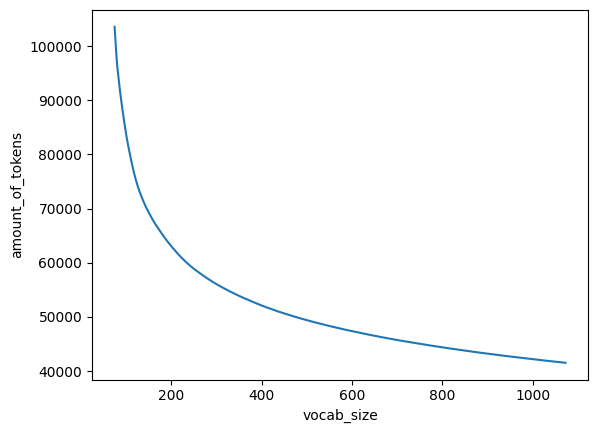

In [17]:
# according to plot choose vocab_size=50
import matplotlib.pyplot as plt
plt.plot(x, y)
plt.xlabel("vocab_size")
plt.ylabel("amount_of_tokens")

In [18]:
tokens = list(set(" ".join(train_text + val_text)))
tokens.append("#")
tokens.append("*")
stoi = {s : i for i, s in enumerate(tokens)}
itos = {i : s for s, i in stoi.items()}

new_tokens = []
seq = [stoi[ch] for ch in " ".join(train_text)]

initial_vocab_size = len(tokens)
vocab_size = 90
size = initial_vocab_size

for i in range(vocab_size-initial_vocab_size):
    stat = calc_stat(seq)
    stat = sorted(stat.items(), key=lambda x: -x[1])
    if stat[0][1] == 1:
        break
    new_token = itos[stat[0][0][0]] + itos[stat[0][0][1]]
    new_tokens.append(new_token)
    size += 1
    stoi[new_token] = size - 1
    itos[size - 1] = new_token
    seq = merge(seq, stat[0][0], size - 1)

print(f"amount of tokens = {len(seq)}\nvocab_size = {len(tokens) + len(new_tokens)}")

amount of tokens = 89748
vocab_size = 90


In [19]:
print(tokens)

['ю', 'ё', '-', 'e', 'р', 'й', 'm', '?', 'о', 'ч', ',', 'y', 'я', 'ъ', '\n', 'в', 's', 'd', 'д', 'щ', 'ц', 'a', 'q', 'г', 'п', '.', 'z', 'p', '–', ';', 'l', 'е', 'x', 'i', 'k', 'w', 'б', 'g', '5', ' ', 'c', 'n', 'л', '’', 'з', 't', 'м', '—', 'у', '(', 'ш', 'х', 'h', 'н', 'r', 'o', 'b', 'э', 'и', 'ж', ':', 'v', 'f', 'ф', 'u', 'ь', 'т', 'а', 'к', 'ы', '!', ')', 'с', '#', '*']


In [20]:
print(new_tokens)

[' с', ',\n', ' п', ' в', ' н', 'но', ' о', 'ст', 'ен', 'ет', 'ра', 'и ', 'ро', 'то', ', ']


*Comment: in this task we have only 38 different tokens, so let's use one-hot encoding.*

In [21]:
import torch
import torch.utils.data as data

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

In [22]:
# let write encoder and decoder
def encode(s):
    seq = list(s)
    for i in range(0, len(new_tokens)):
        pair = new_tokens[i]
        idx = 0
        new_seq = []
        while idx < len(seq):
            if idx+1 < len(seq) and seq[idx] + seq[idx+1] == pair:
                idx += 2
                new_seq.append(pair)
            else:
                new_seq.append(seq[idx])
                idx += 1
        seq = new_seq
    arr = [stoi[ch] for ch in seq]
    return arr

def decode(arr):
    s = ""
    for i in arr:
        s += itos[i]
    return s

In [23]:
# check
arr = encode("кот в мешке")
print(arr)
for i in arr:
    print(i, ":", itos[i], "|", sep="")
decode(arr)

[68, 8, 66, 78, 39, 46, 31, 50, 68, 31]
68:к|
8:о|
66:т|
78: в|
39: |
46:м|
31:е|
50:ш|
68:к|
31:е|


'кот в мешке'

In [24]:
# because i gonna use batches during training i need a seq of fixed len
# so lets find it
stats = []
for s in train_sonnets:
    for j in s:
        j = j.lstrip().lower()
        j = "".join([c for c in j if c not in rubbish])
        enc = encode(j.lstrip().lower())
        stats.append(len(enc))

156


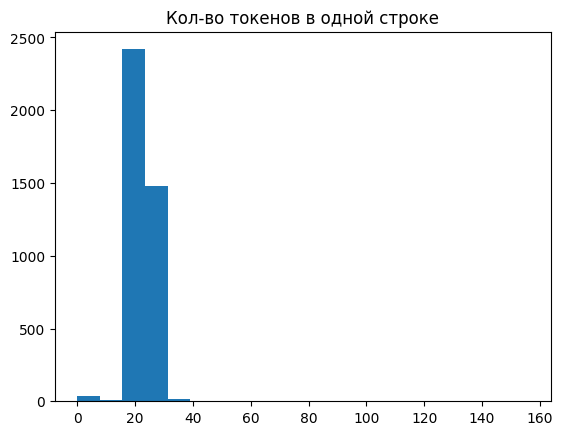

In [25]:
plt.hist(stats, bins=20)
plt.title('Кол-во токенов в одной строке')
print(max(stats))

In [26]:
print(train_text[10])

и вот по родственным обедам
развозят таню каждый день
представить бабушкам и дедам
ее рассеянную лень.
родне, прибывшей издалеча,
повсюду ласковая встреча,
и восклицанья, и хлеб-соль.
как таня выросла! давно ль
я, кажется, тебя крестила?
а я так на руки брала!
а я так за уши драла!
а я так пряником кормила!
и хором бабушки твердят:
как наши годы-то летят!



In [27]:
class dataset(data.Dataset):
    def __init__(self, sonnets_array, context_len):
        x_ds = []
        y_ds = []
        length = 0
        for sonnet in sonnets_array:
            for line in sonnet:
                line = line.lstrip().lower()
                if len(line) < 5:
                    break
                line = "".join([c for c in line if c not in rubbish])
                enc = encode(line.lstrip().lower())
                enc_size = len(enc)
                if enc_size > context_len:
                    enc = [stoi['*']] + enc[:context_len-1] 
                enc = [stoi['*']] + enc + [stoi['#']] * (context_len - enc_size)
                x_ds.append(enc[:-1])
                y_ds.append(enc[1:])
                length += 1
                
        self.x = torch.tensor(x_ds, dtype=torch.int64)
        self.y = torch.tensor(y_ds, dtype=torch.int64)
        self.length = length
    def __getitem__(self, item):
        return self.x[item], self.y[item]
        
    def __len__(self):
        return self.length

### Building the model

Now we want to build and train recurrent neural net which would be able to something similar to Shakespeare's poetry.

Let's use vanilla RNN, similar to the one created during the lesson.

In [28]:
class vanilla_cell (nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_state_size):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_size)
        self.h0 = nn.Embedding(1, hidden_state_size)
        self.rnn_cell = nn.RNNCell(emb_size, hidden_state_size, nonlinearity="tanh")
        self.clf_head = nn.Linear(hidden_state_size, vocab_size)
        
    def forward(self, x, prev_hs):
        if prev_hs == None:
            prev_hs = self.h0(torch.zeros((x.shape[0], 1), dtype=torch.int64))
            prev_hs = prev_hs.view((prev_hs.shape[0], -1))
        x_emb = self.emb(x).view((x.shape[0], -1))
        hs = self.rnn_cell(x_emb, prev_hs)
        logits = self.clf_head(hs)
        return hs, logits     

In [29]:
def rnn_loop(rnn_cell, batch_x):
    batch_size, seq_length = batch_x.size()
    hid_state = None
    logprobs = []

    for x_tmp in batch_x.transpose(0, 1): # shape = object_len, bs, emb_dim
        hid_state, logits = rnn_cell(x_tmp, hid_state) 
        logprobs.append(F.log_softmax(logits, -1))
    
    return torch.stack(logprobs, dim=1)

In [87]:
#hyperparams:
batch_size = 128
emb_size = 12
hidden_state_size = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#vocab_size = 52

#params
#context_len = max(stats)
context_len = 15

In [88]:
train_ds = dataset(train_sonnets, context_len)
train_loader = data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)

val_ds = dataset(val_sonnets, context_len)
val_loader = data.DataLoader(val_ds, batch_size=batch_size, shuffle=True)

In [85]:
for t in train_loader:
    print(decode(t[0][100].numpy()))
    break

**раздался хижин


In [61]:
len(train_ds), len(val_ds)

(3760, 891)

In [62]:
vanilla = vanilla_cell(vocab_size, emb_size, hidden_state_size)
criterion = nn.NLLLoss()
opt = torch.optim.Adam(vanilla.parameters()) 

train_loss=[]
train_acc=[]
val_loss=[]
val_acc=[]

Plot the loss function (axis X: number of epochs, axis Y: loss function).

In [63]:
epochs=200

for _e in range(epochs):
    loss_mean = 0
    accuracy_mean = 0
    lm_count = 0
    train_tqdm = tqdm(train_loader, leave=False)
    for x_b, y_b in train_tqdm:
        logprobs_seq = rnn_loop(vanilla, x_b)
        #-------------------
        mask = y_b.unsqueeze(2).expand(-1, -1, vocab_size) == stoi['#']
        logprobs_seq = logprobs_seq.masked_fill(mask, 0)
        #-------------------
        loss = criterion(
                        logprobs_seq.view(-1, vocab_size),
                        y_b.view(-1),
                        )
        opt.zero_grad()
        loss.backward()
        opt.step()

        lm_count += 1
        loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean

        preds = torch.argmax(logprobs_seq, dim=-1)
        accuracy = (preds == y_b)[y_b != 38].sum() / y_b.numel()
        accuracy_mean = 1/lm_count * accuracy.item() + (1 - 1/lm_count) * accuracy_mean
    
        train_tqdm.set_description(f"Epoch [{_e+1}/{epochs}], loss_mean={loss_mean:.3f}")
    train_loss.append(loss_mean)
    train_acc.append(accuracy_mean)
    
    loss_mean = 0
    accuracy_mean = 0
    lm_count = 0
    val_tqdm = tqdm(val_loader, leave=False)
    with torch.no_grad():
        for x_val, y_val in val_tqdm:
            logprobs_seq = rnn_loop(vanilla, x_val)
            #-------------------
            mask = y_val.unsqueeze(2).expand(-1, -1, vocab_size) == stoi['#']
            logprobs_seq = logprobs_seq.masked_fill(mask, 0)
            #-------------------
            loss = criterion(
                            logprobs_seq.view(-1, vocab_size),
                            y_val.view(-1),
                            )
            lm_count += 1
            loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean
            
            preds = torch.argmax(logprobs_seq, dim=-1)
            accuracy = (preds == y_val)[y_val != 38].sum() / y_val.numel()
            accuracy_mean = 1/lm_count * accuracy.item() + (1 - 1/lm_count) * accuracy_mean
    
            val_tqdm.set_description(f"Epoch [{_e+1}/{epochs}], loss_mean={loss_mean:.3f}")
    val_loss.append(loss_mean)
    val_acc.append(accuracy_mean)

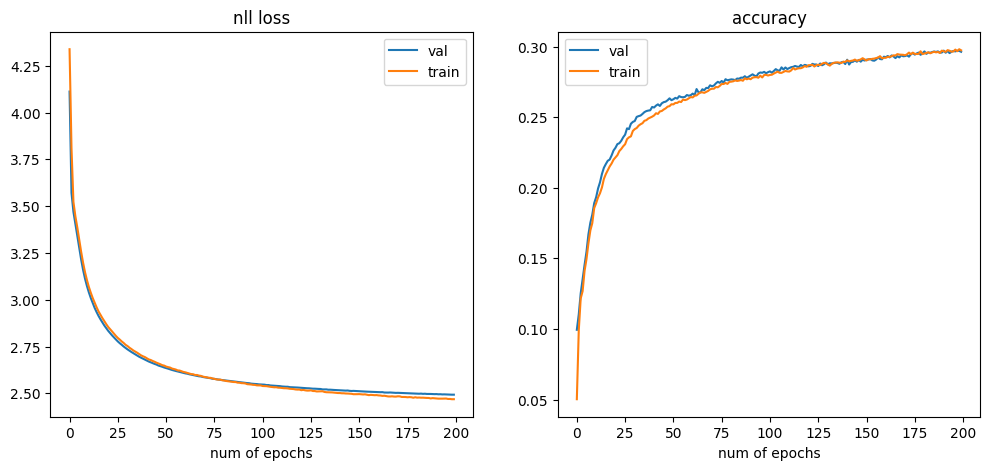

In [64]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(val_loss, label="val")
plt.plot(train_loss, label="train")
plt.title("nll loss")
plt.xlabel("num of epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_acc, label="val")
plt.plot(train_acc, label="train")
plt.title("accuracy")
plt.xlabel("num of epochs")
plt.legend()

In [67]:
text = []
text.append(stoi["*"])
token = torch.tensor([[stoi["*"]]], dtype=torch.int64)
hs = None
temp = 1
with torch.no_grad():
    for i in range(0, 500):
        hs, logits = vanilla(token, hs)
        prob = F.softmax(logits / temp, dim=-1)[0]
        token = torch.multinomial(prob, 1)
        text.append(token.item())
        token = torch.tensor([[token]], dtype=torch.int64)

In [68]:
print(decode(text))

**вы кличу ваби, отгыей вотатью барачих мелись пос звадно склшам списти и вотка н текои данылив естмон, бадеют едне на гздесять в серсце всесмелись и ное,
 насравал взило кы шувой, мак очевгуж рабрие дерденье,
,
не пожденние но другутяста так кочнике рособлив.
,
 том u-си кризнили та селихи быгит и мальей достленные соподает, вде неб оней д неб годым отъыразгруче закой моя она я, навольному вно нь набтиска свепужныским оновескоб бежда жидо бали рюбчагляг,
ныю с сельной вастам плардиласы
 на по думою стравщя: могней странать позьвочных так на впростнольнука ра, у наслычень глежка ра


In [69]:
# An example of generated text. There is no function `generate_text` in the code above.
# print(generate_text(length=500, temperature=0.2))

### More poetic model

Let's use LSTM instead of vanilla RNN and compare the results.

Plot the loss function of the number of epochs. Does the final loss become better?

In [70]:
class lstm_cell (nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_state_size=32):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_size)
        self.h0 = nn.Embedding(1, hidden_state_size)
        self.c0 = nn.Embedding(1, hidden_state_size)
        self.lstm_cell = nn.LSTMCell(emb_size, hidden_state_size)
        self.clf_head = nn.Linear(hidden_state_size, vocab_size)
        
    def forward(self, x, prev_hs):
        if prev_hs == None:
            h1 = self.h0(torch.zeros((x.shape[0], 1), dtype=torch.int64)).view((x.shape[0], -1))
            h2 = self.c0(torch.zeros((x.shape[0], 1), dtype=torch.int64)).view((x.shape[0], -1))
            prev_hs = (h1, h2)
        x_emb = self.emb(x).view((x.shape[0], -1))
        hs = self.lstm_cell(x_emb, prev_hs)
        logits = self.clf_head(hs[0])
        return hs, logits 

In [89]:
lstm = lstm_cell(vocab_size, emb_size, hidden_state_size=32)
criterion = nn.NLLLoss()
opt = torch.optim.Adam(lstm.parameters()) 

train_loss=[]
train_acc=[]
val_loss=[]
val_acc=[]

In [90]:
epochs=200

for _e in range(epochs):
    loss_mean = 0
    accuracy_mean = 0
    lm_count = 0
    train_tqdm = tqdm(train_loader, leave=False)
    for x_b, y_b in train_tqdm:
        logprobs_seq = rnn_loop(lstm, x_b)
        #-------------------
        mask = y_b.unsqueeze(2).expand(-1, -1, vocab_size) == stoi['#']
        logprobs_seq = logprobs_seq.masked_fill(mask, 0)
        #-------------------
        loss = criterion(
                        logprobs_seq.view(-1, vocab_size),
                        y_b.view(-1),
                        )
        opt.zero_grad()
        loss.backward()
        opt.step()

        lm_count += 1
        loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean

        preds = torch.argmax(logprobs_seq, dim=-1)
        accuracy = (preds == y_b)[y_b != 38].sum() / y_b.numel()
        accuracy_mean = 1/lm_count * accuracy.item() + (1 - 1/lm_count) * accuracy_mean
    
        train_tqdm.set_description(f"Epoch [{_e+1}/{epochs}], loss_mean={loss_mean:.3f}")
    train_loss.append(loss_mean)
    train_acc.append(accuracy_mean)
    
    loss_mean = 0
    accuracy_mean = 0
    lm_count = 0
    val_tqdm = tqdm(val_loader, leave=False)
    with torch.no_grad():
        for x_val, y_val in val_tqdm:
            logprobs_seq = rnn_loop(lstm, x_val)
            #-------------------
            mask = y_val.unsqueeze(2).expand(-1, -1, vocab_size) == stoi['#']
            logprobs_seq = logprobs_seq.masked_fill(mask, 0)
            #-------------------
            loss = criterion(
                            logprobs_seq.view(-1, vocab_size),
                            y_val.view(-1),
                            )
            lm_count += 1
            loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean
            
            preds = torch.argmax(logprobs_seq, dim=-1)
            accuracy = (preds == y_val)[y_val != 38].sum() / y_val.numel()
            accuracy_mean = 1/lm_count * accuracy.item() + (1 - 1/lm_count) * accuracy_mean
    
            val_tqdm.set_description(f"Epoch [{_e+1}/{epochs}], loss_mean={loss_mean:.3f}")
    val_loss.append(loss_mean)
    val_acc.append(accuracy_mean)

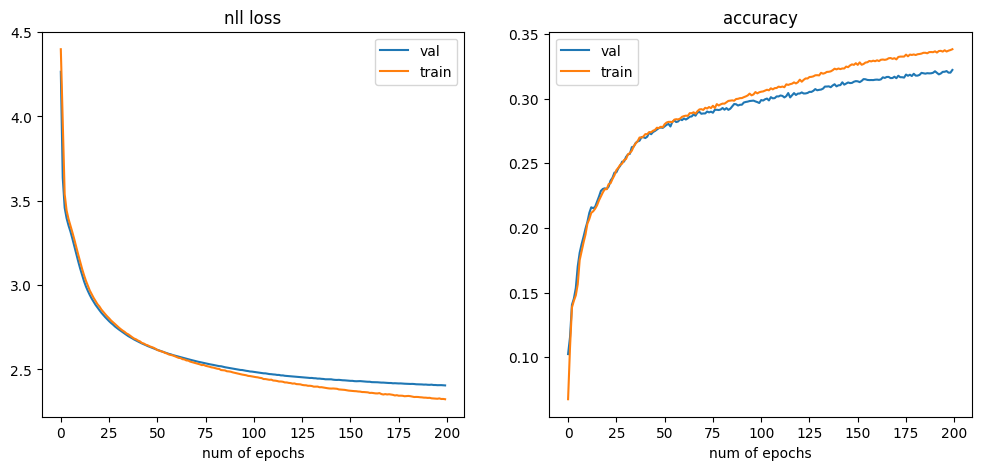

In [91]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(val_loss, label="val")
plt.plot(train_loss, label="train")
plt.title("nll loss")
plt.xlabel("num of epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_acc, label="val")
plt.plot(train_acc, label="train")
plt.title("accuracy")
plt.xlabel("num of epochs")
plt.legend()

Generate text using the trained net with different `temperature` parameter: `(0.1, 0.2, 0.5, 1.0, 2.0)`.

Evaluate the results visually, try to interpret them.

In [94]:
text = []
text.append(stoi["*"])
token = torch.tensor([[stoi["*"]]], dtype=torch.int64)
hs = None
temp = 0.4
with torch.no_grad():
    for i in range(0, 500):
        hs, logits = lstm(token, hs)
        prob = F.softmax(logits / temp, dim=-1)[0]
        token = torch.multinomial(prob, 1)
        text.append(token.item())
        token = torch.tensor([[token]], dtype=torch.int64)

In [95]:
print(decode(text))

**и в давовить извой меже душит долька куко мов мого утребе исперего дольбовой мочный там и полка равось блездалатей несесе мылько что бедала разный полусь из беменный долько дерей молка его былненье бельне тем онегин был был так заком уж любливовала было кому молся листно знавою чуть измолись его любы мезда и совлетный что был до дередь из таня, не шездаливали мой так догда дольки свовило так что блазал как молся вздал достала жеют первалать на чих был мотельной быльской молким беревний когда был и на мой такой закак бы


### Saving and loading models

Save the model to the disk, then load it and generate text.
Follow guides from [this tutorial](https://pytorch.org/tutorials/beginner/saving_loading_models.html).

You need to use `Save/Load state_dict (Recommended)` section aka save state dict.

In [429]:
torch.save(lstm.state_dict(), f'lstm.pth')

In [436]:
model = torch.load('lstm.pth')

## Additional materials on topic

1. [Andrew Karpathy blog post about RNN.](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)\
There are several examples of genration: Shakespeare texts, Latex formulas, Linux Sourse Code and children names.
2. <a href='https://github.com/karpathy/char-rnn'> Repo with char-rnn code </a>
3. Cool repo with [PyTorch examples](https://github.com/spro/practical-pytorch`)